In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")
DICTIONARY_DIR = Path("../dictionaries")

if not DATA_DIR.exists():
    DATA_DIR = Path("data")

if not DICTIONARY_DIR.exists():
    DICTIONARY_DIR = Path("dictionaries")

SAMOKAT_MAIN_PATH = DATA_DIR / "samokat_esci.csv"

DOMAIN_DICTIONARY_PATH = DICTIONARY_DIR / "domain_dictionary.txt"


# предпроцессинг

чистим запросы пользователей перед обработкой

In [54]:
import pandas as pd
import numpy as np 

df = pd.read_csv(SAMOKAT_MAIN_PATH, encoding='utf-8')

preprocessing = df.copy()
preprocessing['query'] = preprocessing['query'].str.lower().str.replace(
    r'[^\p{L}\s-]', '', regex=True
)

preprocessing['query'] = preprocessing['query'].apply(
    lambda q: ' '.join(w for w in q.split() if len(w) > 1) if pd.notna(q) else q
)


In [27]:
es_queries = preprocessing[preprocessing['final_answer'].isin(['e', 's'])]
es_queries = es_queries.dropna(subset='category1_name')

query_category_nunique = es_queries.groupby('query')['category1_name'].nunique()

unambiguous_queries = query_category_nunique[query_category_nunique == 1].index
es_queries = es_queries[es_queries['query'].isin(unambiguous_queries)]

category_counts = es_queries.groupby('category1_name')['query'].nunique()

# Структура данных

| Колонка | Описание | Пример |
|---|---|---|
| query | Поисковый запрос пользователя (9 496 уникальных). Часто содержит опечатки | энергетик без сахара |
| item_name | Название товара из каталога (35 202 уникальных) | энергетик самокат, без сахара, с соком малины, 0,33 л |
| item_id | Уникальный идентификатор товара | 55e4ae6a298cf3... |
| final_answer | Оценка релевантности: E (exact – точное соответствие), S (substitute – заменитель), C (complement – дополнение), I (irrelevant – нерелевантный) | e |
| category4_name | Категория товара, уровень 4 (самый детальный) | энергетические напитки |
| category3_name | Категория товара, уровень 3 | энергетические напитки |
| category2_name | Категория товара, уровень 2 | напитки |
| category1_name | Категория товара, уровень 1 (самый общий) | безалкогольные напитки |


Всего около 9 500 уникальных запросов. К каждому запросу приставлено несколько кандидатов-товаров

In [18]:
colorscale = [
    [0.00, "#FFFFFF"],   
    [0.01, "#FF8FA3"],  
    [0.35, "#FF3357"],
    [0.60, "#CC0024"],
    [0.80, "#99001B"],
    [1.00, "#660012"],   
]

In [19]:
import plotly.graph_objects as go
import plotly.colors as pc

order = ['e', 's', 'c', 'i']
labels_ru = {'e': 'Exact', 's': 'Substitute', 'c': 'Complement', 'i': 'Irrelevant'}
bar_colors = [pc.sample_colorscale(colorscale, [t])[0] for t in [0.55, 0.42, 0.32, 0.22]]

counts = df['final_answer'].value_counts()
values = [int(counts.get(k, 0)) for k in order]
total = sum(values)
percents = [v / total * 100 for v in values]

fig = go.Figure(go.Bar(
    x=percents,
    y=[labels_ru[k] for k in order],
    orientation='h',
    marker=dict(color=bar_colors),
    text=[f'{v:,} ({p:.1f}%)' for v, p in zip(values, percents)],
    textposition='outside',
    textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color='#0b0b0b'),
    hovertemplate='%{y}: %{text}<extra></extra>',
))

fig.update_layout(
    title=dict(
        text='Разметка датасета Самокат: E/S/C/I',
        font=dict(size=16, color='#0b0b0b'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(title='% пар запрос-товар', range=[0, max(percents) * 1.25], showgrid=False, ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='#fcfcfb',
    plot_bgcolor='#fcfcfb',
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    margin=dict(l=10, r=60, t=60, b=40),
    height=350, width=800,
    showlegend=False,
)
fig.show()



In [28]:
import plotly.graph_objects as go
import plotly.colors as pc

df_plot = category_counts.sort_values(ascending=False).reset_index()
df_plot.columns = ['category1_name', 'count']

brand_colorscale = [
    [0.00, "#FFFFFF"],   
    [0.01, "#FF8FA3"],  
    [0.35, "#FF3357"],
    [0.60, "#CC0024"],
    [0.80, "#99001B"],
    [1.00, "#660012"],   
]

norm = (df_plot['count'] - df_plot['count'].min()) / (df_plot['count'].max() - df_plot['count'].min())
norm = 0.05 + 0.95 * norm

tile_colors = pc.sample_colorscale(brand_colorscale, norm.tolist())

def luminance(rgb_str):
    r, g, b = [int(v) for v in rgb_str.strip('rgb()').split(',')]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

text_colors = ['#ffffff' if luminance(c) < 140 else '#0b0b0b' for c in tile_colors]

fig = go.Figure(go.Treemap(
    labels=df_plot['category1_name'],
    parents=[''] * len(df_plot),
    values=df_plot['count'],
    marker=dict(colors=tile_colors, line=dict(width=2, color='#fcfcfb'), pad=dict(t=6, l=3, r=3, b=3)),
    text=[f'{c:,}' for c in df_plot['count']],
    texttemplate='<b>%{label}</b><br>%{text}',
    textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color=text_colors),
    hovertemplate='<b>%{label}</b><br>запросов: %{value:,}<extra></extra>',
    tiling=dict(pad=2),
))

fig.update_layout(
    title=dict(
        text='запросы клиентов Самокат',
        font=dict(size=16, color='#0b0b0b'),
        x=0.02, xanchor='left',
    ),
    paper_bgcolor='#fcfcfb',
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
    margin=dict(l=10, r=10, t=60, b=10),
    height=650, width=1000,
)

fig.show()

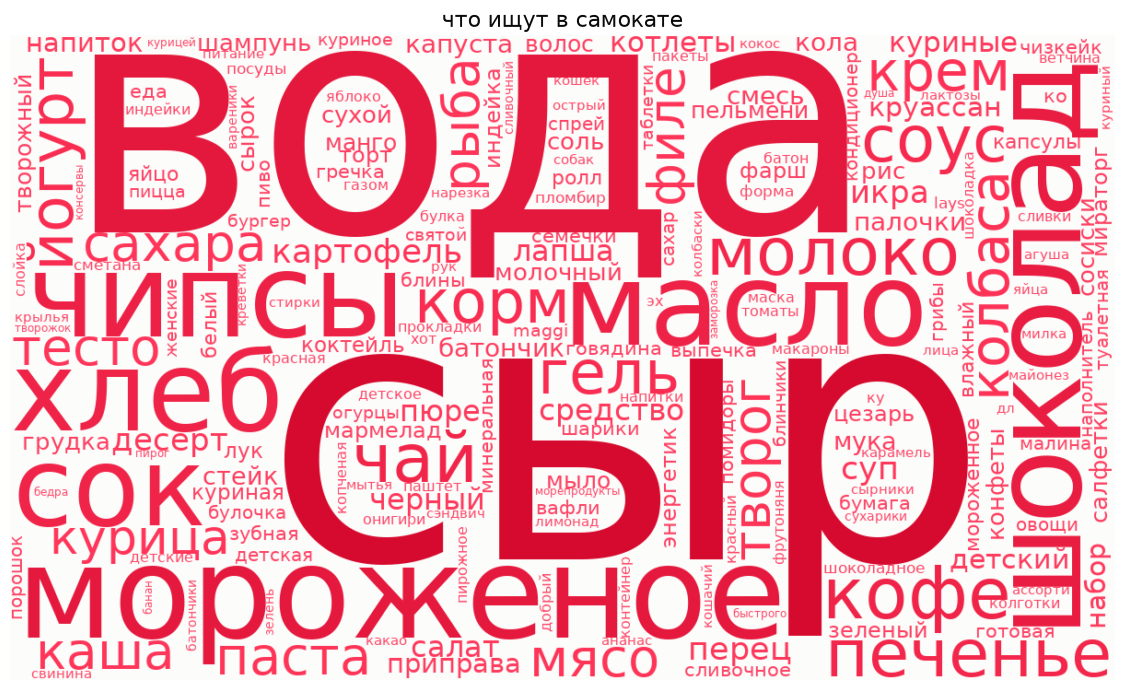

In [ ]:
import os
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud
import matplotlib
import matplotlib.pyplot as plt
import plotly.colors as pc
from collections import Counter

nltk.download('stopwords', quiet=True)
ru_stopwords = set(nltk_stopwords.words('russian')) | {'самокат'}

query_words = (
    preprocessing['query']
    .drop_duplicates()
    .dropna()
    .str.split()
    .explode()
)
query_words = query_words[~query_words.isin(ru_stopwords) & (query_words.str.len() >= 2)]
word_freq = Counter(query_words)

max_freq = word_freq.most_common(1)[0][1]
min_freq = min(word_freq.values())

def brand_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    t = 0.25 + 0.3 * (word_freq[word] - min_freq) / (max_freq - min_freq)
    return pc.sample_colorscale(colorscale, [t])[0]


font_path = os.path.join(os.path.dirname(matplotlib.__file__), 'mpl-data', 'fonts', 'ttf', 'DejaVuSans.ttf')

wc = WordCloud(
    width=1200, height=700,
    background_color='#fcfcfb',
    color_func=brand_color_func,
    max_words=200,
    prefer_horizontal=0.9,
    font_path=font_path,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('что ищут в самокате', fontsize=16, color='#0b0b0b')
plt.tight_layout()
plt.show()


Примеры запросов и кандидатов

In [ ]:
df[df['query'] == 'картофельмялка'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
146,картофельмялка,"чеснок, 3 шт.",i
2557,картофельмялка,"варёный картофель, 500 г",c
3495,картофельмялка,"вермишель самокат на перепелиных яйцах, 300 г",i
8032,картофельмялка,"ассорти макарон самокат, детские, 250 г",i
23537,картофельмялка,"картофелемялка rondell ginger, chocolate",e


In [ ]:
df[df['query'] == 'антисекс'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
1540,антисекс,"средство дезинфицирующее самокат для рук, с ар...",i
17847,антисекс,"аэрозоль от клещей и комаров gardex baby, для ...",i
18365,антисекс,"спрей для рук haan освежающий манхэттен, очище...",i
19216,антисекс,"средство педикулицидное gardex от вшей и гнид,...",i
21493,антисекс,антисептик антисептол 5 л,i


In [ ]:
df[df['query'] == 'домики для тараканов'][['query', 'item_name', 'final_answer']][0:5]

,query,item_name,final_answer
400,домики для тараканов,"ряженка домик в деревне, 2,1%, груша, 260 г",i
2996,домики для тараканов,"домик кукольный edufun с аксессуарами, 8112, 1...",i
3987,домики для тараканов,домик кукольный enchantimals бал в королевском...,i
6980,домики для тараканов,"сливочное масло домик в деревне, 72,5%, 180 г",i
8394,домики для тараканов,подсвечник домик quanzhou qingyi,i


# С какими данными мы работаем? 

https://habr.com/ru/companies/kuper/articles/826316/ - опыт купера
https://habr.com/ru/companies/sbermegamarket/articles/673614/ - опыт сбермегамаркета

Большинство запросов содержит опечатки

In [29]:
from collections import Counter

cols = ['item_name', 'category1_name', 'category2_name', 'category3_name', 'category4_name']
cleaned_cols = [preprocessing[c].str.lower().str.replace(r'[^\p{L}\s-]', '', regex=True) for c in cols]

words = pd.concat(cleaned_cols, ignore_index=True).str.split().explode()
words = words[words.str.len() >= 2]

hyphen_parts = words[words.str.contains('-')].str.split('-').explode()
words = pd.concat([words, hyphen_parts], ignore_index=True)
words = words[words.str.len() >= 2]

dictionary = set(words.dropna())
dictionary = {w for w in dictionary if any(ch.isalpha() for ch in w)}

word_freq = Counter(words.dropna())


def is_correct(query):
    query = query.split()

    for word in query: 
        if word not in dictionary: 
            return False
    return True

preprocessing['is_correct'] = preprocessing['query'].apply(lambda q: is_correct(q))
unique_queries = preprocessing[['query', 'is_correct']].drop_duplicates(subset=['query'])

print(f"Всего уникальных запросов: {len(unique_queries['query'])}")
print(f"Из них запросов с опечатками: {len(unique_queries[unique_queries['is_correct'] == False])}")

Всего уникальных запросов: 9228
Из них запросов с опечатками: 4458


несколько примеров запросов

In [30]:
(
    preprocessing[preprocessing['is_correct'] == False][['query', 'item_name']]
    .rename(columns={'query': 'запрос', 'item_name': 'товар-кандидат'})[80:90]
)



,запрос,товар-кандидат
160,консервативные ананас,"протёртые лимон и имбирь самокат, с сахаром, 2..."
161,сордел,"шербет самокат, 2%, двухслойный, с чёрной и кр..."
162,сгушонная малако,"имбирь молотый noyer сушеный натуральный, инди..."
165,аруассаны,"круассаны 7 days мини, с ванильным кремом, 300 г"
168,сок апель,"апельсиновый сок j7 fresh taste, 0,3 л"
169,тмк батон,"батон тагилхлеб подмосковный, в нарезке, 330 г"
172,лабуба,напиток чайный vinut popping boba bubble tea m...
173,икрв,икра осетровая русское море стольная имитирова...
176,нэнер,"энергетик lit energy original, без сахара, 0,45 л"
177,лук пррей,"красный лук, 500 г"


## Типология опечаток в запросах

### 1. Недописанные / усечённые слова 
- творог мя - творог мягкий
- палочки шокола - палочки шокололадные
- протеиновы - протеиновый
- туал - туалетная
- кисломи - кисломикс
- кокт - коктейль
- мультизлаков - мультизлаковая
- пластиковая лож - пластиковая ложка
- соус майо - соус майонез
- шпина - шпинат
- шарики для сти - шарики для стирки
- круасс - круассан
- пшен - пшеннная
- газиров - газировка
- горчиц зерна - горчица зерна
- коктейль фист - коктейль фисташковый
- вода газир - вода газированная

### 2. Лишняя буква
- готовая едаз - готовая еда
- эйогурт - йогурт
- вода без газаз - вода без газа
- гранолаэ - гранола

### 3. Лишнее слово / обрывок названия бренда
- ром до - ром до
- соломка ка - соломка ка
- даниссимо ими - даниссимо ими
- же дезодоранты - же дезозоранты
- халва ку - халва ку

### 4. Перепутанные буквы
- мароконы - макароны
- пивк - пиво
- йоугор - йогурт
- ьворожный - творожный
- салëные огурец - соленый огурец
- снсиска - сосиска
- соломкс - соломка
- сгушонная малако - сгущенное молоко
- кокороз - кукуруза
- эвервеч - эвервейс
- клубникю - клубника
- лвйм - лайм
- донисоимо - даниссимо
- туалетная ьумагп - туалетная бумага
- картоыель - картофель
- оуассан - круассан
- онегирт - онигири 
- серистый творог - зернистый творог
- маршмкллов - маршмеллоу

### 5. Слипшиеся слова (нет пробела)
- бриошараматизаторь - бриошь ароматизатор
- твороженныйсвр - творожный сыр
- туалетнаябцмага - туалетная бумага
- укропбатон - укроп батон

### 6. Слово случайно разбито пробелом
- го овые - готовые
- ананаса ку сочки - ананаса кусочки

### 7. Смешанные / сложные случаи
- череизов - черкизово
- чайлипто - чай липтон
- щербетмороженное - щербет мороженное
- консервативные ананас - консервированные ананасы
- мясо индейу - мясо индейки
- перецчер - перец черный 
- чупа куё - чупа чупс
- агар агара - агар агар
- муз из манки - ???

### 8. Запросы на иностранном языке
- exponents
- nike vaprofly
- florida котят

### 9. Запросы без ошибок
- леденец на палочке петушок
- power банк беспроводной
- швабра для полов
- газировка
- малина
- корм кошачий perfect fit
- сердце желудки


# Как мы работаем с опечатками

ручная выборка запросов с опечатками для проверки решения

In [31]:
typo_test_set = [

    ("творог мя", "недописанное_слово", "творог мягкий"),
    ("палочки шокола", "недописанное_слово", "палочки шоколад"),
    ("протеиновы", "недописанное_слово", "протеиновый"),
    ("туал", "недописанное_слово", "туалетная"),
    ("кисломи", "недописанное_слово", "кисломикс"),
    ("кокт", "недописанное_слово", "коктейль"),
    ("мультизлаков", "недописанное_слово", "мультизлаковая"),
    ("пластиковая лож", "недописанное_слово", "пластиковая ложка"),
    ("соус майо", "недописанное_слово", "соус майонез"),
    ("шпина", "недописанное_слово", "шпинат"),
    ("шарики для сти", "недописанное_слово", "шарики для стирки"),
    ("круасс", "недописанное_слово", "круассан"),
    ("пшен", "недописанное_слово", "пшеничное"),
    ("газиров", "недописанное_слово", "газировка"),
    ("горчиц зерна", "недописанное_слово", "горчица зерна"),
    ("коктейль фист", "недописанное_слово", "коктейль фисташковый"),
    ("икра искусств", "недописанное_слово", "икра искусственная"),
    ("влажные салф", "недописанное_слово", "влажные салфетки"), 
    ("каш", "недописанное_слово", "каша"), 
    ("корм для кош", "недописанное_слово", "корм для кошек"),
    ("сгущен", "недописанное_слово", "сгущенное"),
    

    ("готовая едаз", "лишняя_буква", "готовая еда"),
    ("эйогурт", "лишняя_буква", "йогурт"),
    ("вода без газаз", "лишняя_буква", "вода без газа"),
    ("гранолаэ", "лишняя_буква", "гранола"),

    ("ром до", "лишнее_слово_или_бренд", "ром до"),
    ("соломка ка", "лишнее_слово_или_бренд", "соломка ка"),
    ("даниссимо ими", "лишнее_слово_или_бренд", "даниссимо ими"),
    ("же дезодоранты", "лишнее_слово_или_бренд", "же дезозоранты"),
    ("халва ку", "лишнее_слово_или_бренд", "халва ку"),

    ("мароконы", "перепутаны_буквы", "макароны"),
    ("пивк", "перепутаны_буквы", "пиво"),
    ("йоугор", "перепутаны_буквы", "йогурт"),
    ("ьворожный", "перепутаны_буквы", "творожный"),
    ("салëные огурец", "перепутаны_буквы", "соленый огурец"),
    ("снсиска", "перепутаны_буквы", "сосиска"),
    ("соломкс", "перепутаны_буквы", "соломка"),
    ("сгушонная малако", "перепутаны_буквы", "сгущенное молоко"),
    ("кокороз", "перепутаны_буквы", "кукуруза"),
    ("эвервеч", "перепутаны_буквы", "эвервейс"),
    ("клубникю", "перепутаны_буквы", "клубника"),
    ("лвйм", "перепутаны_буквы", "лайм"),
    ("донисоимо", "перепутаны_буквы", "даниссимо"),
    ("туалетная ьумагп", "перепутаны_буквы", "туалетная бумага"),
    ("картоыель", "перепутаны_буквы", "картофель"),
    ("оуассан", "перепутаны_буквы", "круассан"),
    ("онегирт", "перепутаны_буквы", "онигири"),

    ("бриошараматизаторь", "слипшиеся_слова", "бриошь ароматизатор"),
    ("твороженныйсвр", "слипшиеся_слова", "творожный сыр"),
    ("туалетнаябцмага", "слипшиеся_слова", "туалетная бумага"),
    ("укропбатон", "слипшиеся_слова", "укроп батон"),

    ("го овые", "разделено_пробелом", "готовые"),
    ("ананаса ку сочки", "разделено_пробелом", "ананаса кусочки"),

    ("череизов", "сложный_случай", "черкизово"),
    ("чайлипто", "сложный_случай", "чай липтон"),
    ("щербетмороженное", "сложный_случай", "щербет мороженное"),
    ("консервативные ананас", "сложный_случай", "консервированные ананасы"),
    ("мясо индейу", "сложный_случай", "мясо индейки"),
    ("перецчер", "сложный_случай", "перец черный"),
    ("чупа куё", "сложный_случай", "чупа чупс"),
    ("агар агара", "сложный_случай", "агар агар"),
    ("муз из манки", "сложный_случай", "муз из манки"),
    ("чипсызреновые", "сложный_случай", "чипсы зерновые"),

    ("exponents", "иностранный_язык", "exponents"),
    ("nike vaprofly", "иностранный_язык", "nike vaprofly"),
    ("florida котят", "иностранный_язык", "florida котят"),

    ("леденец на палочке петушок", "норм", "леденец на палочке петушок"),
    ("power банк беспроводной", "норм", "power банк беспроводной"),
    ("швабра для полов", "норм", "швабра для полов"),
    ("газировка", "норм", "газировка"),
    ("малина", "норм", "малина"),
    ("корм кошачий perfect fit", "норм", "корм кошачий perfect fit"),
    ("сердце желудки", "норм", "сердце желудки"),
]

typo_test_df = pd.DataFrame(typo_test_set, columns=['query', 'error_type', 'expected'])
typo_test_df.to_csv('typo_test_set.csv', index=False, encoding='utf-8')


In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()


def lemmatize_text(text):
    return ' '.join(morph.parse(word)[0].normal_form for word in text.split())

In [32]:
def evaluate_typos(corrected_queries, test_df=typo_test_df):
    result = test_df.copy()
    result['corrected'] = list(corrected_queries)

    labeled = result[result['expected'].notna()].copy()
    labeled['is_match'] = (
        labeled['corrected'].apply(lemmatize_text) == labeled['expected'].apply(lemmatize_text)
    )
    result['is_match'] = pd.NA
    result.loc[labeled.index, 'is_match'] = labeled['is_match']

    accuracy = labeled['is_match'].mean()
    accuracy_by_type = labeled.groupby('error_type')['is_match'].mean().sort_values()

    print(f"Точность: {accuracy:.1%}  ({labeled['is_match'].sum()} из {len(labeled)} примеров)")
    print("-" * 40)
    for error_type, acc in accuracy_by_type.items():
        print(f"{error_type:<30} {acc:>6.1%}")

    mistakes = labeled.loc[~labeled['is_match'], ['query', 'expected', 'corrected']].rename(
    columns={'query': 'запрос', 'expected': 'ожидали', 'corrected': 'получили'}
)

    if not mistakes.empty:
        print()
        print(f"Ошибки ({len(mistakes)}):")
        print(mistakes.to_string(index=False))

    return result, accuracy, accuracy_by_type


Подход 1: чистый symspellpy

In [ ]:
from symspellpy import SymSpell, Verbosity

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(DOMAIN_DICTIONARY_PATH, 0, 1, separator=' ', encoding='utf-8')

DISTANCE_PENALTY = 10

def correct_word(word, max_edit_distance=2):
    if word in dictionary:
        return word

    candidates = sym_spell.lookup(word, Verbosity.ALL, max_edit_distance=max_edit_distance)
    if candidates:
        best = max(candidates, key=lambda s: s.count / (DISTANCE_PENALTY ** s.distance))
        return best.term

    segmentation = sym_spell.word_segmentation(word, max_edit_distance=max_edit_distance)
    parts = segmentation.corrected_string.split()
    if (
        len(parts) > 1
        and all(p in dictionary for p in parts)
        and segmentation.distance_sum <= max_edit_distance
        and all(word_freq.get(p, 0) >= 3 for p in parts)
    ):
        return segmentation.corrected_string

    return word


def correct_query(query, max_edit_distance=2):
    query = query.strip()
    words = query.split()
    return ' '.join(correct_word(w, max_edit_distance) for w in words)


In [36]:
corrected_1 = typo_test_df['query'].apply(lambda q: correct_query(q))
report_1, acc_1, by_type_1 = evaluate_typos(corrected_1)

Точность: 53.4%  (39 из 73 примеров)
----------------------------------------
разделено_пробелом               0.0%
сложный_случай                  30.0%
недописанное_слово              33.3%
слипшиеся_слова                 50.0%
лишнее_слово_или_бренд          60.0%
иностранный_язык                66.7%
перепутаны_буквы                70.6%
лишняя_буква                    75.0%
норм                           100.0%

Ошибки (34):
               запрос                  ожидали              получили
            творог мя            творог мягкий           творог мясо
                 туал                туалетная                  тела
              кисломи                кисломикс             кислотами
                 кокт                 коктейль                   кот
      пластиковая лож        пластиковая ложка      пластиковая кожи
            соус майо             соус майонез              соус чай
       шарики для сти        шарики для стирки        шарики для сыр
              

Подход 2: symspellpy + prefix + pymorphy

In [ ]:
import re

LATIN_RE = re.compile(r'^[a-zA-Z]+$')

def correct_word_prefix(word, max_edit_distance=2):
    if LATIN_RE.match(word):
        return word

    if word in dictionary:
        return word

    if morph.word_is_known(word):
        return word

    if len(word) >= 2:
        completions = trie.keys(word)
        if completions:
            return max(completions, key=lambda w: word_freq.get(w, 0))

    candidates = sym_spell.lookup(word, Verbosity.ALL, max_edit_distance=max_edit_distance)
    if candidates:
        best = max(candidates, key=lambda s: s.count / (DISTANCE_PENALTY ** s.distance))
        return best.term

    segmentation = sym_spell.word_segmentation(word, max_edit_distance=max_edit_distance)
    parts = segmentation.corrected_string.replace('-', ' ').split()
    if (
        len(parts) > 1
        and all(p in dictionary for p in parts)
        and segmentation.distance_sum <= max_edit_distance * len(parts)
    ):
        return ' '.join(parts)

    return word


def correct_query_prefix(query, max_edit_distance=2):
    words = query.strip().split()

    merged_words = []
    i = 0
    while i < len(words):
        word = words[i]

        if word in dictionary or LATIN_RE.match(word):
            merged_words.append(word)
            i += 1
            continue

        if i + 1 < len(words) and words[i + 1] not in dictionary:
            merged = word + words[i + 1]
            if merged in dictionary:
                merged_words.append(merged)
                i += 2
                continue

            candidates = sym_spell.lookup(merged, Verbosity.CLOSEST, max_edit_distance=max_edit_distance)
            if candidates:
                best = max(candidates, key=lambda s: s.count / (DISTANCE_PENALTY ** s.distance))
                merged_words.append(best.term)
                i += 2
                continue

        merged_words.append(word)
        i += 1

    return ' '.join(correct_word_prefix(w, max_edit_distance) for w in merged_words)


In [38]:
corrected_2 = typo_test_df['query'].apply(lambda q: correct_query_prefix(q))
report_2, acc_2, by_type_2 = evaluate_typos(corrected_2)

Точность: 75.3%  (55 из 73 примеров)
----------------------------------------
разделено_пробелом              50.0%
сложный_случай                  60.0%
перепутаны_буквы                70.6%
недописанное_слово              71.4%
лишняя_буква                    75.0%
лишнее_слово_или_бренд          80.0%
иностранный_язык               100.0%
норм                           100.0%
слипшиеся_слова                100.0%

Ошибки (18):
               запрос                  ожидали              получили
            творог мя            творог мягкий           творог мясо
      пластиковая лож        пластиковая ложка       пластиковая лож
              газиров                газировка          газированные
        коктейль фист     коктейль фисташковый     коктейль фисташки
        икра искусств       икра искусственная         икра искусств
         корм для кош           корм для кошек          корм для кош
         готовая едаз              готовая еда          готовая глаз
       же дезо

Подход 2: sage-fred5-distiled

In [39]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

sage_path = "/Users/mishanya/Desktop/models/sage-fredt5-distilled-95m"
sage_tokenizer = AutoTokenizer.from_pretrained(sage_path)
sage_model = AutoModelForSeq2SeqLM.from_pretrained(sage_path).to('mps')

def correct_query_sage(query):
    inputs = sage_tokenizer(
        query, max_length=None, padding='longest', truncation=False, return_tensors='pt'
    ).to(sage_model.device)
    outputs = sage_model.generate(**inputs, max_length=int(inputs['input_ids'].shape[1] * 1.5))
    result = sage_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return result.strip().rstrip('.!?').lower()

corrected_3 = typo_test_df['query'].apply(correct_query_sage)
report_3, acc_3, by_type_3 = evaluate_typos(corrected_3)

Точность: 34.2%  (25 из 73 примеров)
----------------------------------------
разделено_пробелом               0.0%
перепутаны_буквы                17.6%
сложный_случай                  20.0%
недописанное_слово              23.8%
слипшиеся_слова                 25.0%
лишнее_слово_или_бренд          60.0%
норм                            71.4%
лишняя_буква                    75.0%
иностранный_язык               100.0%

Ошибки (48):
                    запрос                    ожидали                     получили
                 творог мя              творог мягкий                    творог мя
                протеиновы                протеиновый                   протеиновы
                      туал                  туалетная                          тул
                   кисломи                  кисломикс                      кисломи
                      кокт                   коктейль                         кокт
              мультизлаков             мультизлаковая               

Подход 3: дообучение своей модели

на будущее

Выводы

In [40]:
category_order = [
    'недописанное_слово',
    'лишняя_буква',
    'лишнее_слово_или_бренд',
    'перепутаны_буквы',
    'слипшиеся_слова',
    'разделено_пробелом',
    'сложный_случай',
    'иностранный_язык',
    'норм',
]

pretty_names = {
    'недописанное_слово': 'недописанное слово',
    'лишняя_буква': 'лишняя буква',
    'лишнее_слово_или_бренд': 'лишнее слово или бренд',
    'перепутаны_буквы': 'перепутаны буквы',
    'слипшиеся_слова': 'слипшиеся слова',
    'разделено_пробелом': 'разделено пробелом',
    'сложный_случай': 'сложный случай',
    'иностранный_язык': 'иностранный язык',
    'норм': 'норм слово',
}
pretty_order = [pretty_names[c] for c in category_order]

comparison = pd.DataFrame({
    'symspell': by_type_1,
    'symspell + prefix': by_type_2,
    'sage-fredt5': by_type_3,
})
comparison = comparison.reindex(category_order)
comparison.loc['ИТОГО'] = [acc_1, acc_2, acc_3]
comparison = comparison.rename(index=pretty_names).rename_axis('тип опечатки')

(
    comparison
    .style
    .format('{:.1%}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None, subset=pd.IndexSlice[pretty_order, :])
    .set_properties(subset=pd.IndexSlice[['ИТОГО'], :], **{'font-weight': 'bold', 'border-top': '2px solid black'})
    .set_caption('точность исправления опечаток')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '17px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th', 'props': [('font-size', '14px'), ('padding', '8px 14px')]},
        {'selector': 'td', 'props': [('font-size', '14px'), ('padding', '8px 14px'), ('text-align', 'center')]},
    ])
    .set_properties(**{'min-width': '110px'})
)

,symspell,symspell + prefix,sage-fredt5
тип опечатки,,,
недописанное слово,33.3%,71.4%,23.8%
лишняя буква,75.0%,75.0%,75.0%
лишнее слово или бренд,60.0%,80.0%,60.0%
перепутаны буквы,70.6%,70.6%,17.6%
слипшиеся слова,50.0%,100.0%,25.0%
разделено пробелом,0.0%,50.0%,0.0%
сложный случай,30.0%,60.0%,20.0%
иностранный язык,66.7%,100.0%,100.0%
норм слово,100.0%,100.0%,71.4%


Можно сравнить наши результаты с результатами работы инженеров из Сбера

ссылка на статью - https://habr.com/ru/companies/sbermegamarket/articles/673614/

!['сбер'](images/sbermegamarket.png)


# Кластеризация запросов

Для векторизации мы будем использовать: e5-small, sbert_large_nlu, bge-m3

In [42]:
import umap
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN

In [43]:
e5_model = SentenceTransformer('d0rj/e5-small-en-ru')

In [ ]:
path = "/Users/mishanya/Desktop/models/sbert_large_nlu_ru"
sbert_model = SentenceTransformer(path, device='mps')

In [44]:
reducer = umap.UMAP(random_state=228, n_components=15, metric='cosine', n_neighbors=10, min_dist=0.0,)
clusterer = HDBSCAN(min_cluster_size=20, min_samples=15)

эмбеддинги с опечатками

In [45]:
queries = preprocessing['query'].unique()
queries_prefixed = [f"query: {q}" for q in queries] # необходимо, чтобы e5 работал корректно

e5_embeddings = e5_model.encode(queries_prefixed, convert_to_numpy=True, show_progress_bar=True)
print(f'ембеддинги e5: {e5_embeddings.shape}')


Batches:   0%|          | 0/289 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Ембеддинги e5: (9228, 384)


In [46]:
X_reduced_e5 = reducer.fit_transform(e5_embeddings)

clustered_e5 = clusterer.fit_predict(X_reduced_e5)

n_clusters_e5 = len(set(clustered_e5))
n_noise_e5 = (clustered_e5 == -1).sum()

clustered_df_e5 = pd.DataFrame({'query': queries, 'cluster': clustered_e5})

/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [47]:
from tqdm.auto import tqdm

queries_cleaned = [correct_query_prefix(q) for q in tqdm(preprocessing['query'].unique())]
queries_cleaned_prefixed = [f"query: {q}" for q in queries_cleaned]

e5_embeddings_cleaned = e5_model.encode(queries_cleaned_prefixed, convert_to_numpy=True, show_progress_bar=True)
print(f'эмбеддинги e5 (очищенные): {e5_embeddings_cleaned.shape}')

  0%|          | 0/9228 [00:00<?, ?it/s]

Batches:   0%|          | 0/289 [00:00<?, ?it/s]

эмбеддинги e5 (очищенные): (9228, 384)


In [143]:
reducer = umap.UMAP(random_state=228, n_components=15, metric='cosine', n_neighbors=10, min_dist=0.0,)
clusterer = HDBSCAN(min_cluster_size=20, min_samples=15)

In [144]:
X_reduced_e5_cleaned = reducer.fit_transform(e5_embeddings_cleaned)

clustered_e5_cleaned = clusterer.fit_predict(X_reduced_e5_cleaned)

n_clusters_e5_cleaned = len(set(clustered_e5_cleaned))
n_noise_e5_cleaned = (clustered_e5_cleaned == -1).sum()

clustered_df_e5_cleaned = pd.DataFrame({'query': queries_cleaned, 'cluster': clustered_e5_cleaned})


/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [145]:
def plot_clusters_3d_comparison(datasets, titles=None, top_clusters=None, n_top=8,
                                 palette=None, random_state=228, width=1100, height=480,
                                 gap=0.04, background_sample=0.15):
    
    DEFAULT_PALETTE = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
                    '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']

    palette = DEFAULT_PALETTE
    n = len(datasets)
    titles = titles or [f'вариант {i + 1}' for i in range(n)]
    slot_width = (1 - gap * (n - 1)) / n

    fig = go.Figure()

    axis_style = dict(
        visible=False,
    )
    scene_layout = {}
    annotations = []
    rng = np.random.default_rng(random_state)

    for idx, (embeddings, clustered_labels, queries) in enumerate(datasets):
        queries_arr = np.array(queries)

        clusters = top_clusters
        if clusters is None:
            sizes = pd.Series(clustered_labels[clustered_labels != -1]).value_counts()
            clusters = sizes.head(n_top).index.tolist()

        reducer_3d = umap.UMAP(n_components=3, metric='cosine', random_state=random_state)
        X_viz_3d = reducer_3d.fit_transform(embeddings)

        scene_id = 'scene' if idx == 0 else f'scene{idx + 1}'

        def subsample(mask, frac=background_sample):
            idxs = np.flatnonzero(mask)
            keep = rng.choice(idxs, size=int(len(idxs) * frac), replace=False) if len(idxs) else idxs
            sub_mask = np.zeros_like(mask)
            sub_mask[keep] = True
            return sub_mask

        noise_mask = subsample(clustered_labels == -1)
        fig.add_trace(go.Scatter3d(
            x=X_viz_3d[noise_mask, 0], y=X_viz_3d[noise_mask, 1], z=X_viz_3d[noise_mask, 2],
            mode='markers', marker=dict(size=1, color='#c3c2b7', opacity=0.2),
            text=queries_arr[noise_mask], hovertemplate='%{text}<extra></extra>',
            name='шум', scene=scene_id, showlegend=(idx == 0),
        ))

        other_mask = subsample((clustered_labels != -1) & ~np.isin(clustered_labels, clusters))
        if other_mask.any():
            fig.add_trace(go.Scatter3d(
                x=X_viz_3d[other_mask, 0], y=X_viz_3d[other_mask, 1], z=X_viz_3d[other_mask, 2],
                mode='markers', marker=dict(size=1.2, color='#898781', opacity=0.3),
                text=queries_arr[other_mask], hovertemplate='%{text}<extra></extra>',
                name='другое', scene=scene_id, showlegend=(idx == 0),
            ))

        for i, (color, c) in enumerate(zip(palette, clusters), start=1):
            mask = clustered_labels == c
            fig.add_trace(go.Scatter3d(
                x=X_viz_3d[mask, 0], y=X_viz_3d[mask, 1], z=X_viz_3d[mask, 2],
                mode='markers', marker=dict(size=2.2, color=color, opacity=0.7),
                text=queries_arr[mask], hovertemplate='%{text}<extra></extra>',
                name=f'кластер {i}', scene=scene_id, showlegend=(idx == 0),
            ))

        x0 = idx * (slot_width + gap)
        x1 = x0 + slot_width
        scene_layout[scene_id] = dict(
            xaxis=axis_style, yaxis=axis_style, zaxis=axis_style,
            domain=dict(x=[x0, x1], y=[0.05, 0.95]),
        )
        annotations.append(dict(
            text=titles[idx], x=x0 + slot_width / 2, y=1.0,
            xref='paper', yref='paper', showarrow=False, font=dict(size=14),
        ))

    fig.update_layout(
        **scene_layout,
        annotations=annotations,
        width=width, height=height,
        legend=dict(x=1.02, y=0.5),
        margin=dict(l=10, r=10, t=30, b=10),
    )
    fig.show()
    return fig


In [146]:
plot_clusters_3d_comparison(
    [
        (e5_embeddings, clustered_e5, queries),
        (e5_embeddings_cleaned, clustered_e5_cleaned, queries_cleaned),
    ],
    titles=['до очистки', 'после очистки'],
);

/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [147]:
noise_before = clustered_e5 == -1
noise_after = clustered_e5_cleaned == -1

n_clusters_before = len(set(clustered_e5[~noise_before]))
n_clusters_after = len(set(clustered_e5_cleaned[~noise_after]))

avg_size_before = pd.Series(clustered_e5[~noise_before]).value_counts().mean()
avg_size_after = pd.Series(clustered_e5_cleaned[~noise_after]).value_counts().mean()

metrics = pd.DataFrame({
    'до': [f'{noise_before.mean():.1%}', n_clusters_before, f'{avg_size_before:.1f}'],
    'после': [f'{noise_after.mean():.1%}', n_clusters_after, f'{avg_size_after:.1f}'],
}, index=['доля шума', 'число кластеров', 'средний размер кластера'])

(
    metrics
    .style
    .set_caption('кластеризация: до и после спелчекера')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '17px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th', 'props': [('font-size', '14px'), ('padding', '10px 18px')]},
        {'selector': 'td', 'props': [('font-size', '15px'), ('padding', '10px 18px'), ('text-align', 'center'), ('font-weight', '600')]},
    ])
)


,до,после
доля шума,25.3%,22.9%
число кластеров,159,150
средний размер кластера,43.4,47.5


In [148]:
rescued_mask = noise_before & ~noise_after

rescued_examples = pd.DataFrame({
    'исходный запрос': np.array(queries)[rescued_mask],
    'после очистки': np.array(queries_cleaned)[rescued_mask],
    'попал в кластер №': clustered_e5_cleaned[rescued_mask],
})

print(f'были шумом → попали в кластер: {rescued_mask.sum()}')
rescued_examples.sample(min(10, len(rescued_examples)), random_state=1).reset_index(drop=True)


были шумом → попали в кластер: 1407


,исходный запрос,после очистки,попал в кластер №
0,горячая,горячая,18
1,смдии,мидии,80
2,анализы,анализы,124
3,ароматизаторов,ароматизаторов,7
4,крекеры,крекеры,56
5,клейх,клей,88
6,молочный десерт бисквитом,молочный десерт бисквитом,92
7,сушеная пыб,сушеная сыр,66
8,крукса,кукла,119
9,обучающая зайка,обучающая зайка,109


In [81]:
import pymorphy3
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

try:
    stopwords.words('russian')
except LookupError:
    nltk.download('stopwords')

morph = pymorphy3.MorphAnalyzer()
stopwords_lemmatized = list(set(morph.parse(w)[0].normal_form for w in stopwords.words('russian')))


def lemmatize(text):
    return ' '.join(morph.parse(word)[0].normal_form for word in text.split())


In [85]:
def plot_treemap(clustered_df, title='запросы пользователей самокат', n_top_words=1, width=1000, height=650):
    queries_by_cluster = clustered_df.groupby('cluster')['query'].apply(lambda x: x.str.cat(sep=' '))
    documents_lemmatized = queries_by_cluster.apply(lemmatize)

    vectorizer = TfidfVectorizer(stop_words=stopwords_lemmatized)
    tfidf_matrix = vectorizer.fit_transform(documents_lemmatized)

    df_tfidf = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=documents_lemmatized.index,
    )

    top_words = {
        cluster: df_tfidf.loc[cluster].sort_values(ascending=False).head(n_top_words).index.tolist()
        for cluster in df_tfidf.index
    }
    cluster_names = {cluster: ' / '.join(words) for cluster, words in top_words.items()}

    clustered_df = clustered_df.copy()
    clustered_df['cluster_name'] = clustered_df['cluster'].map(cluster_names).fillna('шум')

    df_plot = (
        clustered_df[clustered_df['cluster'] != -1]
        .groupby(['cluster', 'cluster_name'])['query']
        .nunique()
        .sort_values(ascending=False)
        .reset_index()
    )
    df_plot.columns = ['cluster', 'cluster_name', 'count']

    brand_colorscale = [
        [0.00, "#FFFFFF"],
        [0.01, "#FF8FA3"],
        [0.35, "#FF3357"],
        [0.60, "#CC0024"],
        [0.80, "#99001B"],
        [1.00, "#660012"],
    ]

    norm = (df_plot['count'] - df_plot['count'].min()) / (df_plot['count'].max() - df_plot['count'].min())
    norm = 0.05 + 0.95 * norm
    tile_colors = pc.sample_colorscale(brand_colorscale, norm.tolist())

    def luminance(rgb_str):
        r, g, b = [int(v) for v in rgb_str.strip('rgb()').split(',')]
        return 0.2126 * r + 0.7152 * g + 0.0722 * b

    text_colors = ['#ffffff' if luminance(c) < 140 else '#0b0b0b' for c in tile_colors]

    fig = go.Figure(go.Treemap(
        labels=df_plot['cluster_name'],
        parents=[''] * len(df_plot),
        values=df_plot['count'],
        customdata=df_plot['cluster'],
        marker=dict(colors=tile_colors, line=dict(width=2, color='#fcfcfb'), pad=dict(t=6, l=3, r=3, b=3)),
        text=[f'{c:,}' for c in df_plot['count']],
        texttemplate='<b>%{label}</b><br>%{text}',
        textfont=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', size=13, color=text_colors),
        hovertemplate='<b>%{label}</b><br>кластер №%{customdata}<br>запросов: %{value:,}<extra></extra>',
        tiling=dict(pad=2),
    ))

    fig.update_layout(
        title=dict(
            text=f'{title}: {len(df_plot)} категорий',
            font=dict(size=16, color='#0b0b0b'),
            x=0.02, xanchor='left',
        ),
        paper_bgcolor='#fcfcfb',
        font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif'),
        margin=dict(l=10, r=10, t=60, b=10),
        height=height, width=width,
    )
    fig.show()


In [125]:
plot_treemap(clustered_df_e5, title='запросы самокат')

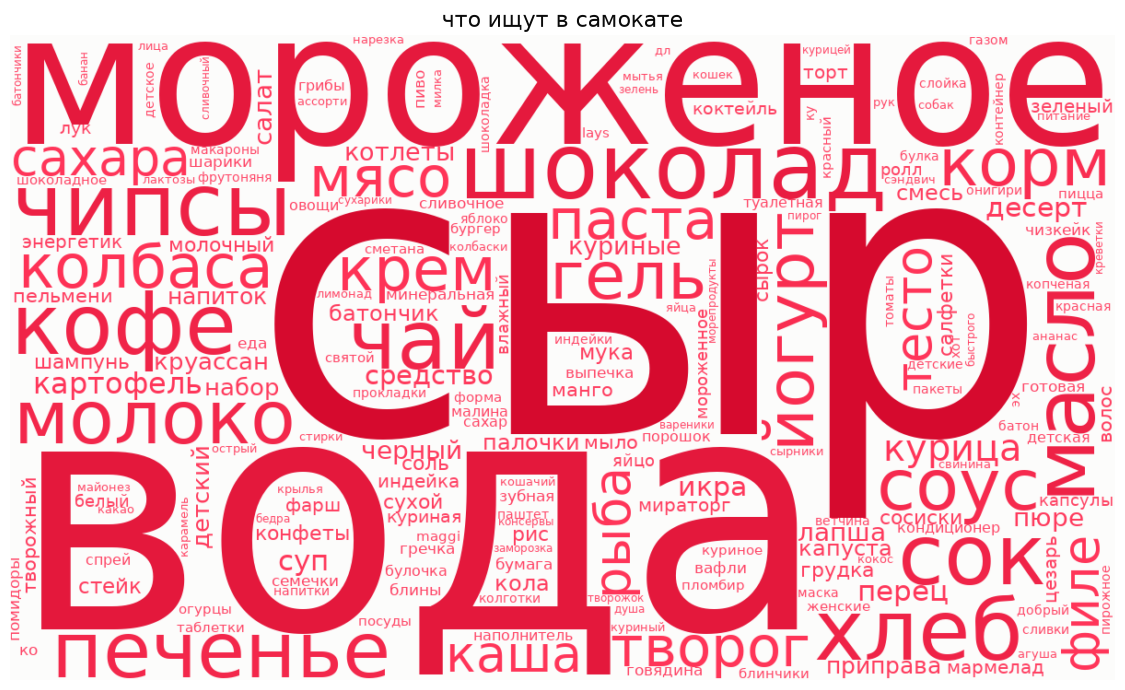

In [111]:
import os
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud
import matplotlib
import matplotlib.pyplot as plt
import plotly.colors as pc
from collections import Counter

nltk.download('stopwords', quiet=True)
ru_stopwords = set(nltk_stopwords.words('russian')) | {'самокат'}

query_words = (
    preprocessing['query']
    .drop_duplicates()
    .dropna()
    .str.split()
    .explode()
)
query_words = query_words[~query_words.isin(ru_stopwords) & (query_words.str.len() >= 2)]
word_freq = Counter(query_words)

max_freq = word_freq.most_common(1)[0][1]
min_freq = min(word_freq.values())

def brand_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    t = 0.25 + 0.3 * (word_freq[word] - min_freq) / (max_freq - min_freq)
    return pc.sample_colorscale(colorscale, [t])[0]


font_path = os.path.join(os.path.dirname(matplotlib.__file__), 'mpl-data', 'fonts', 'ttf', 'DejaVuSans.ttf')

wc = WordCloud(
    width=1200, height=700,
    background_color='#fcfcfb',
    color_func=brand_color_func,
    max_words=200,
    prefer_horizontal=0.9,
    font_path=font_path,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('что ищут в самокате', fontsize=16, color='#0b0b0b')
plt.tight_layout()
plt.show()

In [130]:
clustered_df_e5[clustered_df_e5['cluster'] == 81]

,query,cluster
66,сыр маздас,81
83,мармелад для сыра,81
116,сыр плавленный для бургеров,81
125,сыр масло,81
188,сыр,81
...,...,...
9044,сырбол,81
9070,плавленый кускус,81
9078,сырники лапки,81
9094,сырок бельг,81


In [128]:
clustered_df_e5[clustered_df_e5['cluster'] == 79]

,query,cluster
13,шоколад протеиновы,79
31,сгушонная малако,79
161,гранд коктейль,79
204,цезарь из шоколад,79
254,коктейль фист,79
...,...,...
8921,шоколад злаки,79
9033,милк вэй,79
9158,протеиновый шоколад chika,79
9165,стоячий шоколад,79


In [129]:
clustered_df_e5[clustered_df_e5['cluster'] == 69]

,query,cluster
138,бутылочки для детей,69
148,святой источник манго,69
209,вода без газаз,69
212,газиров,69
287,tassay вода,69
...,...,...
8524,газированная вода газом святой источник,69
8949,водаьгаз,69
8963,минералка газом маленькая,69
9119,вода детский,69


In [149]:
plot_treemap(clustered_df_e5_cleaned, title='запросы самокат после очистки')

In [140]:
clustered_df_e5_cleaned[clustered_df_e5_cleaned['cluster'] == 220]

,query,cluster
36,grands,220
121,arrive,220
123,,220
132,cookies,220
164,hunters,220
...,...,...
9014,axe effect,220
9041,arrive belle you,220
9043,curly,220
9068,counry,220


In [150]:
def cluster_purity(clustered_df, original_queries, preprocessing):
    query_category = (
        preprocessing.dropna(subset=['category1_name'])
        .groupby('query')['category1_name']
        .agg(lambda x: x.mode().iloc[0])
    )

    df = clustered_df.copy()
    df['original_query'] = list(original_queries)
    df['category1_name'] = df['original_query'].map(query_category)
    df = df[(df['cluster'] != -1) & df['category1_name'].notna()]

    purity_by_cluster = df.groupby('cluster')['category1_name'].agg(
        lambda x: x.value_counts(normalize=True).iloc[0]
    )
    cluster_sizes = df.groupby('cluster').size()
    overall_purity = (purity_by_cluster * cluster_sizes).sum() / cluster_sizes.sum()

    return overall_purity, purity_by_cluster, cluster_sizes


purity_before, purity_by_cluster_before, sizes_before = cluster_purity(clustered_df_e5, queries, preprocessing)
purity_after, purity_by_cluster_after, sizes_after = cluster_purity(clustered_df_e5_cleaned, queries, preprocessing)

print(f'Чистота кластеров (взвешенная по размеру):')
print(f'  до очистки:    {purity_before:.1%}')
print(f'  после очистки: {purity_after:.1%}')


Чистота кластеров (взвешенная по размеру):
  до очистки:    40.8%
  после очистки: 38.0%


вывод: чистка примерно нейтральна по чистоте кластеров